In [1]:
## 1. Import Libraries and Set Reproducibility

import os
import random
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf

# Fixed random seed
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

# Request deterministic TensorFlow operations
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


In [2]:
## 2. Mount Google Drive and Load Final Manifests

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/Master_datascience_thesis"

preprocessing_dir = os.path.join(PROJECT_ROOT,"outputs","preprocessing")

model_output_dir = os.path.join( PROJECT_ROOT, "outputs", "deep_learning")

os.makedirs(model_output_dir, exist_ok=True)

train_df = pd.read_csv(os.path.join(preprocessing_dir,"final_train_metadata.csv"))

validation_df = pd.read_csv(os.path.join( preprocessing_dir,"final_validation_metadata.csv"))

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Model output folder ready:",os.path.exists(model_output_dir))

Mounted at /content/drive
Training images: 6480
Validation images: 1794
Model output folder ready: True


In [3]:
## 3. Set Image Location and Resize Size

zip_path = os.path.join(PROJECT_ROOT, "data","TBX11K.zip")

IMAGE_SIZE = (224, 224)

print("TBX11K ZIP found:", os.path.exists(zip_path))
print("Image resize size:", IMAGE_SIZE)

TBX11K ZIP found: True
Image resize size: (224, 224)


Sample path: sick/s0230.png
Image shape: (224, 224, 3)


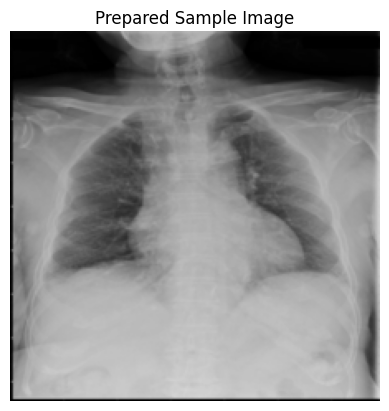

In [4]:
## 4. Load and Prepare One Image

from PIL import Image
import matplotlib.pyplot as plt

# Convert one image to RGB and resize it to 224 x 224
def load_image(zip_file, image_path):
    full_path = "TBX11K/imgs/" + image_path

    with zip_file.open(full_path) as file:
        image = Image.open(file).convert("RGB")
        image = image.resize(
            IMAGE_SIZE,
            Image.Resampling.BILINEAR
        )

    return np.array(image)


# Test with one training image
with zipfile.ZipFile(zip_path, "r") as zip_file:
    sample_path = train_df.iloc[0]["path"]
    sample_image = load_image(zip_file, sample_path)

print("Sample path:", sample_path)
print("Image shape:", sample_image.shape)

plt.imshow(sample_image)
plt.title("Prepared Sample Image")
plt.axis("off")
plt.show()

In [5]:
## 5. Calculate Class Weights

from sklearn.utils.class_weight import compute_class_weight

class_values = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_values,
    y=train_df["label"]
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights:", class_weights)

Class weights: {0: 0.5510204081632653, 1: 5.4}


In [6]:
## 6. Define Training Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor=5 / 360,
        fill_mode="reflect",
        interpolation="bilinear",
        seed=RANDOM_SEED
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="reflect",
        interpolation="bilinear",
        seed=RANDOM_SEED
    ),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.05, 0.05),
        width_factor=(-0.05, 0.05),
        fill_mode="reflect",
        interpolation="bilinear",
        seed=RANDOM_SEED
    )
])

print("Training data augmentation ready")

Training data augmentation ready


In [7]:
## 7. Create Training and Validation Data Generators

BATCH_SIZE = 32

class ImageSequence(tf.keras.utils.Sequence):

    def __init__(self, dataframe, batch_size, shuffle=False):
        super().__init__()

        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.dataframe))

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = start + self.batch_size

        batch_indices = self.indices[start:end]
        batch_df = self.dataframe.iloc[batch_indices]

        images = []

        with zipfile.ZipFile(zip_path, "r") as zip_file:
            for image_path in batch_df["path"]:
                image = load_image(zip_file, image_path)
                images.append(image)

        images = np.array(images, dtype=np.float32)
        labels = batch_df["label"].to_numpy(dtype=np.float32)

        return images, labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_data = ImageSequence(
    train_df,
    BATCH_SIZE,
    shuffle=True
)

validation_data = ImageSequence(
    validation_df,
    BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_data))
print("Validation batches:", len(validation_data))

Training batches: 203
Validation batches: 57


In [8]:
## 8. Check One Training Batch

batch_images, batch_labels = train_data[0]

print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)
print("Image value range:", batch_images.min(), "to", batch_images.max())

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Image value range: 0.0 to 252.0


In [9]:
## 9. Build the ResNet50 Model

# Load the pretrained ResNet50 base model
resnet50_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
resnet50_base.trainable = False

# Build the complete model
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = resnet50_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

resnet50_model = tf.keras.Model(inputs, outputs)

print("ResNet50 model ready")
print("Base model trainable:", resnet50_base.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 model ready
Base model trainable: False


In [10]:
## 10. Compile the ResNet50 Model

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="sensitivity"),
        tf.keras.metrics.AUC(name="auroc")
    ]
)

print("ResNet50 model compiled")

ResNet50 model compiled


In [11]:
## 11. Define ResNet50 Training Callbacks

resnet50_model_path = os.path.join(
    model_output_dir,
    "best_resnet50_model.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=resnet50_model_path,
        monitor="val_auroc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auroc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001,
        verbose=1
    )
]

print("ResNet50 callbacks ready")

ResNet50 callbacks ready


In [12]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
## 12. Train the ResNet50 Model

INITIAL_EPOCHS = 20

resnet50_history = resnet50_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7295 - auroc: 0.7834 - loss: 0.5465 - precision: 0.2052 - sensitivity: 0.6664
Epoch 1: val_auroc improved from None to 0.93175, saving model to /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/best_resnet50_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/best_resnet50_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.7887 - auroc: 0.8623 - loss: 0.4630 - precision: 0.2704 - sensitivity: 0.7550 - val_accuracy: 0.9158 - val_auroc: 0.9318 - val_loss: 0.2458 - val_precision: 0.6079 - val_sensitivity: 0.6900 - learning_rate: 0.0010
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.8958 - auroc: 0.9481 - loss: 0.3006 - precision: 0.4567 - sensitivity: 0.8630
Epoch 2: val_auroc improved from 0.93175 to 0.95499, saving model to /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/best_r

In [14]:
## 13. Load and Evaluate the Best ResNet50 Model

best_resnet50_model = tf.keras.models.load_model(resnet50_model_path)

resnet50_results = best_resnet50_model.evaluate(validation_data, return_dict=True)

for metric_name, metric_value in resnet50_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 707ms/step - accuracy: 0.9409 - auroc: 0.9756 - loss: 0.1745 - precision: 0.6895 - sensitivity: 0.8550
accuracy: 0.9409
auroc: 0.9756
loss: 0.1745
precision: 0.6895
sensitivity: 0.8550


In [15]:
## 14. Generate ResNet50 Validation Predictions

resnet50_probabilities = best_resnet50_model.predict(validation_data).ravel()

resnet50_predictions = (resnet50_probabilities >= 0.5).astype(int)

true_labels = validation_df["label"].to_numpy()

print("Predictions generated:", len(resnet50_predictions))

57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 717ms/step
Predictions generated: 1794


In [16]:
## 15. Calculate ResNet50 Validation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(true_labels,resnet50_predictions).ravel()

specificity = tn / (tn + fp)

resnet50_metrics = {
    "Accuracy": accuracy_score(true_labels, resnet50_predictions),
    "Precision": precision_score(true_labels, resnet50_predictions),
    "Sensitivity": recall_score(true_labels, resnet50_predictions),
    "Specificity": specificity,
    "F1_score": f1_score(true_labels, resnet50_predictions),
    "AUROC": roc_auc_score(true_labels, resnet50_probabilities),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}

for metric_name, metric_value in resnet50_metrics.items():
    print(metric_name, ":", round(metric_value, 4))

Accuracy : 0.9409
Precision : 0.6895
Sensitivity : 0.855
Specificity : 0.9517
F1_score : 0.7634
AUROC : 0.9756
TN : 1517
FP : 77
FN : 29
TP : 171


In [17]:
## 16. Save ResNet50 Validation Results

resnet50_results_df = pd.DataFrame([{
    "Model": "ResNet50",
    **resnet50_metrics
}])

resnet50_results_path = os.path.join(
    model_output_dir,
    "resnet50_validation_results.csv"
)

resnet50_results_df.to_csv(
    resnet50_results_path,
    index=False
)

print("ResNet50 results saved:", resnet50_results_path)

ResNet50 results saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/resnet50_validation_results.csv


In [18]:
## 17. Save ResNet50 Training History

resnet50_history_df = pd.DataFrame(resnet50_history.history)

resnet50_history_path = os.path.join( model_output_dir, "resnet50_training_history.csv")

resnet50_history_df.to_csv(resnet50_history_path, index=False)

print("ResNet50 training history saved:", resnet50_history_path)

ResNet50 training history saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/resnet50_training_history.csv


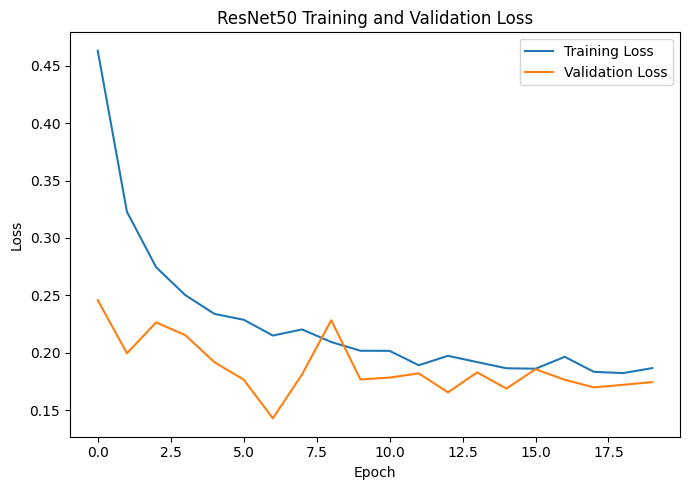

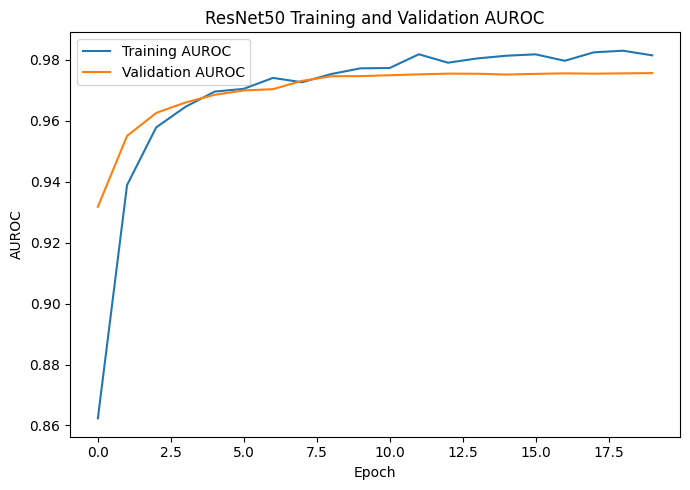

Loss plot saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/resnet50_loss_curve.png
AUROC plot saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/resnet50_auroc_curve.png


In [19]:
## 18. Plot and Save ResNet50 Training History

# Plot and save training and validation loss
plt.figure(figsize=(7, 5))
plt.plot(resnet50_history.history["loss"], label="Training Loss")
plt.plot(resnet50_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(
    model_output_dir,
    "resnet50_loss_curve.png"
)

plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()


# Plot and save training and validation AUROC
plt.figure(figsize=(7, 5))
plt.plot(resnet50_history.history["auroc"], label="Training AUROC")
plt.plot(resnet50_history.history["val_auroc"], label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("ResNet50 Training and Validation AUROC")
plt.legend()
plt.tight_layout()

auroc_plot_path = os.path.join(
    model_output_dir,
    "resnet50_auroc_curve.png"
)

plt.savefig(auroc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss plot saved:", loss_plot_path)
print("AUROC plot saved:", auroc_plot_path)

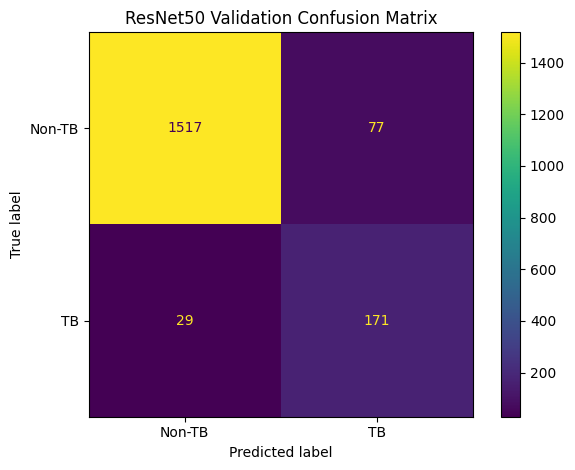

Confusion matrix saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/resnet50_confusion_matrix.png


In [20]:
## 19. Plot and Save ResNet50 Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix_values = np.array([
    [tn, fp],
    [fn, tp]
])

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["Non-TB", "TB"]
)

display.plot(values_format="d")
plt.title("ResNet50 Validation Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = os.path.join(
    model_output_dir,
    "resnet50_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved:", confusion_matrix_path)

In [21]:
## 20. Build the MobileNetV2 Model

mobilenetv2_base = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenetv2_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = mobilenetv2_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

mobilenetv2_model = tf.keras.Model(inputs, outputs)

print("MobileNetV2 model ready")
print("Base model trainable:", mobilenetv2_base.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 model ready
Base model trainable: False


In [22]:
## 21. Compile the MobileNetV2 Model

mobilenetv2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="sensitivity"),
        tf.keras.metrics.AUC(name="auroc")
    ]
)

print("MobileNetV2 model compiled")

MobileNetV2 model compiled


In [23]:
## 22. Define MobileNetV2 Training Callbacks

mobilenetv2_model_path = os.path.join(
    model_output_dir,
    "best_mobilenetv2_model.keras"
)

mobilenetv2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=mobilenetv2_model_path,
        monitor="val_auroc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auroc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001,
        verbose=1
    )
]

print("MobileNetV2 callbacks ready")

MobileNetV2 callbacks ready


In [24]:
## 23. Train the MobileNetV2 Model

mobilenetv2_history = mobilenetv2_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=mobilenetv2_callbacks
)

Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.6896 - auroc: 0.7463 - loss: 0.5972 - precision: 0.1928 - sensitivity: 0.6966
Epoch 1: val_auroc improved from None to 0.91948, saving model to /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/best_mobilenetv2_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/best_mobilenetv2_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 180s 861ms/step - accuracy: 0.7747 - auroc: 0.8492 - loss: 0.4990 - precision: 0.2592 - sensitivity: 0.7717 - val_accuracy: 0.8829 - val_auroc: 0.9195 - val_loss: 0.3374 - val_precision: 0.4841 - val_sensitivity: 0.7600 - learning_rate: 0.0010
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.8559 - auroc: 0.9302 - loss: 0.3630 - precision: 0.3773 - sensitivity: 0.8471
Epoch 2: val_auroc improved from 0.91948 to 0.93647, saving model to /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_lea

In [25]:
## 24. Load and Evaluate the Best MobileNetV2 Model

best_mobilenetv2_model = tf.keras.models.load_model(mobilenetv2_model_path)

mobilenetv2_results = best_mobilenetv2_model.evaluate(validation_data,return_dict=True)

for metric_name, metric_value in mobilenetv2_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 667ms/step - accuracy: 0.9420 - auroc: 0.9595 - loss: 0.1691 - precision: 0.7000 - sensitivity: 0.8400
accuracy: 0.9420
auroc: 0.9595
loss: 0.1691
precision: 0.7000
sensitivity: 0.8400


In [26]:
## 25. Generate MobileNetV2 Validation Predictions

mobilenetv2_probabilities = best_mobilenetv2_model.predict(validation_data).ravel()

mobilenetv2_predictions = (mobilenetv2_probabilities >= 0.5).astype(int)

print("Predictions generated:", len(mobilenetv2_predictions))

57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 672ms/step
Predictions generated: 1794


In [27]:
## 26. Calculate MobileNetV2 Validation Metrics

mobilenetv2_tn, mobilenetv2_fp, mobilenetv2_fn, mobilenetv2_tp = confusion_matrix(
    true_labels,
    mobilenetv2_predictions
).ravel()

mobilenetv2_specificity = (
    mobilenetv2_tn / (mobilenetv2_tn + mobilenetv2_fp)
)

mobilenetv2_metrics = {
    "Accuracy": accuracy_score(true_labels, mobilenetv2_predictions),
    "Precision": precision_score(true_labels, mobilenetv2_predictions),
    "Sensitivity": recall_score(true_labels, mobilenetv2_predictions),
    "Specificity": mobilenetv2_specificity,
    "F1_score": f1_score(true_labels, mobilenetv2_predictions),
    "AUROC": roc_auc_score(true_labels, mobilenetv2_probabilities),
    "TN": mobilenetv2_tn,
    "FP": mobilenetv2_fp,
    "FN": mobilenetv2_fn,
    "TP": mobilenetv2_tp
}

for metric_name, metric_value in mobilenetv2_metrics.items():
    print(metric_name, ":", round(metric_value, 4))

Accuracy : 0.942
Precision : 0.7
Sensitivity : 0.84
Specificity : 0.9548
F1_score : 0.7636
AUROC : 0.9594
TN : 1522
FP : 72
FN : 32
TP : 168


In [28]:
## 27. Save MobileNetV2 Validation Results

mobilenetv2_results_df = pd.DataFrame([{"Model": "MobileNetV2",**mobilenetv2_metrics}])

mobilenetv2_results_path = os.path.join( model_output_dir, "mobilenetv2_validation_results.csv")

mobilenetv2_results_df.to_csv( mobilenetv2_results_path, index=False)

print("MobileNetV2 results saved:", mobilenetv2_results_path)

MobileNetV2 results saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/mobilenetv2_validation_results.csv


In [29]:
## 28. Save MobileNetV2 Training History

mobilenetv2_history_df = pd.DataFrame(mobilenetv2_history.history)

mobilenetv2_history_path = os.path.join(model_output_dir,"mobilenetv2_training_history.csv")

mobilenetv2_history_df.to_csv( mobilenetv2_history_path, index=False)

print("MobileNetV2 training history saved:", mobilenetv2_history_path)

MobileNetV2 training history saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/mobilenetv2_training_history.csv


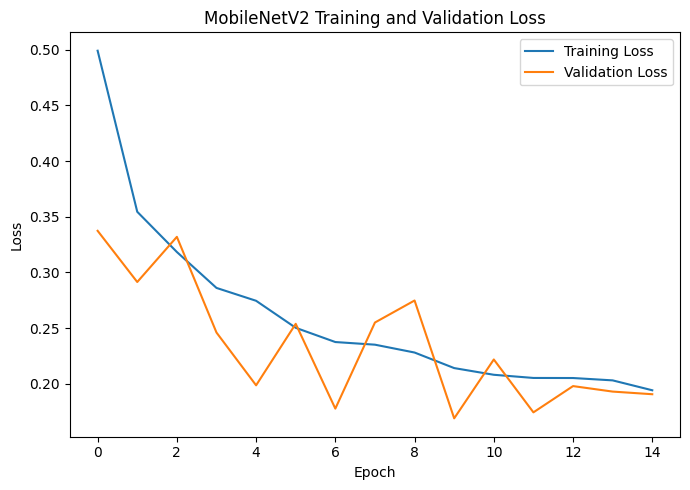

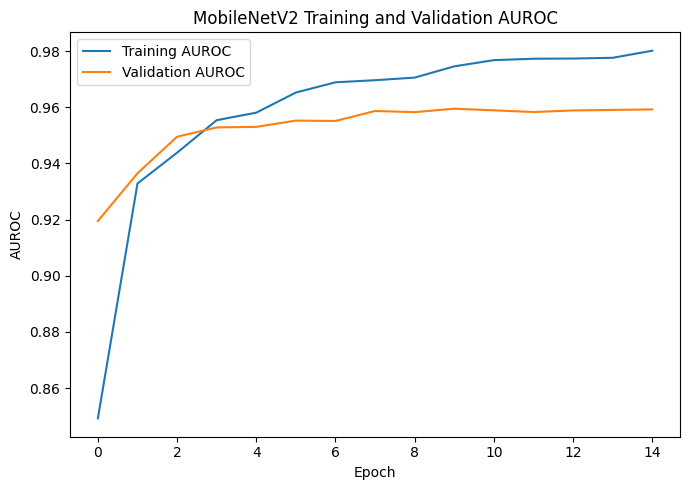

Loss plot saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/mobilenetv2_loss_curve.png
AUROC plot saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/mobilenetv2_auroc_curve.png


In [30]:
## 29. Plot and Save MobileNetV2 Training History

# Plot and save training and validation loss
plt.figure(figsize=(7, 5))
plt.plot(mobilenetv2_history.history["loss"], label="Training Loss")
plt.plot(mobilenetv2_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(model_output_dir,"mobilenetv2_loss_curve.png")

plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()


# Plot and save training and validation AUROC
plt.figure(figsize=(7, 5))
plt.plot(mobilenetv2_history.history["auroc"], label="Training AUROC")
plt.plot(mobilenetv2_history.history["val_auroc"], label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("MobileNetV2 Training and Validation AUROC")
plt.legend()
plt.tight_layout()

auroc_plot_path = os.path.join(model_output_dir, "mobilenetv2_auroc_curve.png")

plt.savefig(auroc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss plot saved:", loss_plot_path)
print("AUROC plot saved:", auroc_plot_path)

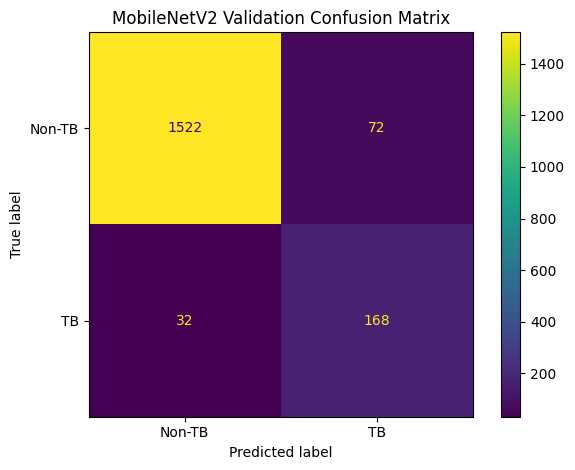

Confusion matrix saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/mobilenetv2_confusion_matrix.png


In [31]:
## 30. Plot and Save MobileNetV2 Confusion Matrix

mobilenetv2_confusion_values = np.array([[mobilenetv2_tn, mobilenetv2_fp],[mobilenetv2_fn, mobilenetv2_tp]])

mobilenetv2_confusion_display = ConfusionMatrixDisplay(confusion_matrix=mobilenetv2_confusion_values,display_labels=["Non-TB", "TB"])

mobilenetv2_confusion_display.plot(values_format="d")
plt.title("MobileNetV2 Validation Confusion Matrix")
plt.tight_layout()

mobilenetv2_confusion_path = os.path.join(model_output_dir,"mobilenetv2_confusion_matrix.png")

plt.savefig(mobilenetv2_confusion_path, dpi=300, bbox_inches="tight")

plt.show()

print("Confusion matrix saved:", mobilenetv2_confusion_path)

In [32]:
## 31. Save Deep-Learning Validation Scores

deep_learning_score_df = validation_df[ ["path", "label"]].reset_index(drop=True).copy()

deep_learning_score_df["ResNet50_score"] = ( resnet50_probabilities)

deep_learning_score_df["MobileNetV2_score"] = ( mobilenetv2_probabilities)

assert len(deep_learning_score_df) == len( resnet50_probabilities)

assert len(deep_learning_score_df) == len( mobilenetv2_probabilities)

deep_learning_score_path = os.path.join(  model_output_dir, "deep_learning_validation_scores.csv")

deep_learning_score_df.to_csv( deep_learning_score_path, index=False)

print("Deep-learning validation scores saved")
print("Rows saved:", len(deep_learning_score_df))
print("File:", deep_learning_score_path)

Deep-learning validation scores saved
Rows saved: 1794
File: /content/drive/MyDrive/Master_datascience_thesis/outputs/deep_learning/deep_learning_validation_scores.csv


In [33]:
## Check Saved CNN Model Files

resnet50_model_path = os.path.join(
    model_output_dir,
    "best_resnet50_model.keras"
)

mobilenetv2_model_path = os.path.join(
    model_output_dir,
    "best_mobilenetv2_model.keras"
)

print(
    "ResNet50 model:",
    os.path.exists(resnet50_model_path),
    os.path.getsize(resnet50_model_path)
    if os.path.exists(resnet50_model_path) else "Missing"
)

print(
    "MobileNetV2 model:",
    os.path.exists(mobilenetv2_model_path),
    os.path.getsize(mobilenetv2_model_path)
    if os.path.exists(mobilenetv2_model_path) else "Missing"
)

ResNet50 model: True 95045619
MobileNetV2 model: True 9645733
